In [16]:
print('Hello')

Hello


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [18]:
df=pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')

In [19]:
df.head()


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [20]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

## Drop day, month, year

In [21]:
df = df.drop(['day', 'month', 'year'], axis=1)

In [23]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [24]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

## Encoding

In [25]:
df['Classes'] = np.where(df['Classes'].str.contains("not fire"),0,1)

In [26]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [27]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [28]:
## Independent and Dependent features
X = df.drop('FWI', axis=1)
y = df['FWI']

In [29]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [30]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

## Train Test Split


In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,y,test_size=0.25, random_state=43)

In [33]:
X_train.shape, X_test.shape

((182, 11), (61, 11))

## Feature selection based on Correlation

In [34]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.659120,-0.313004,-0.329720,0.701060,0.502747,0.393587,0.630473,0.476795,0.565026,0.299316
RH,-0.659120,1.000000,0.312190,0.245762,-0.670875,-0.399709,-0.227840,-0.703401,-0.346836,-0.491651,-0.435075
Ws,-0.313004,0.312190,1.000000,0.160958,-0.227260,-0.019928,0.045396,-0.017229,0.004554,-0.120561,-0.198738
Rain,-0.329720,0.245762,0.160958,1.000000,-0.555931,-0.275293,-0.287197,-0.348926,-0.285114,-0.390323,-0.046784
FFMC,0.701060,-0.670875,-0.227260,-0.555931,1.000000,0.592479,0.493368,0.746844,0.575405,0.782283,0.237565
DMC,0.502747,-0.399709,-0.019928,-0.275293,0.592479,1.000000,0.882414,0.679640,0.984318,0.583017,0.205296
DC,0.393587,-0.227840,0.045396,-0.287197,0.493368,0.882414,1.000000,0.513896,0.949592,0.485008,-0.085764
ISI,0.630473,-0.703401,-0.017229,-0.348926,0.746844,0.679640,0.513896,1.000000,0.637470,0.742329,0.288159
BUI,0.476795,-0.346836,0.004554,-0.285114,0.575405,0.984318,0.949592,0.637470,1.000000,0.567145,0.100737
Classes,0.565026,-0.491651,-0.120561,-0.390323,0.782283,0.583017,0.485008,0.742329,0.567145,1.000000,0.200545


## Check for Multicollinearity

Independent features sd not be that much correlated based on some threshold values

<Axes: >

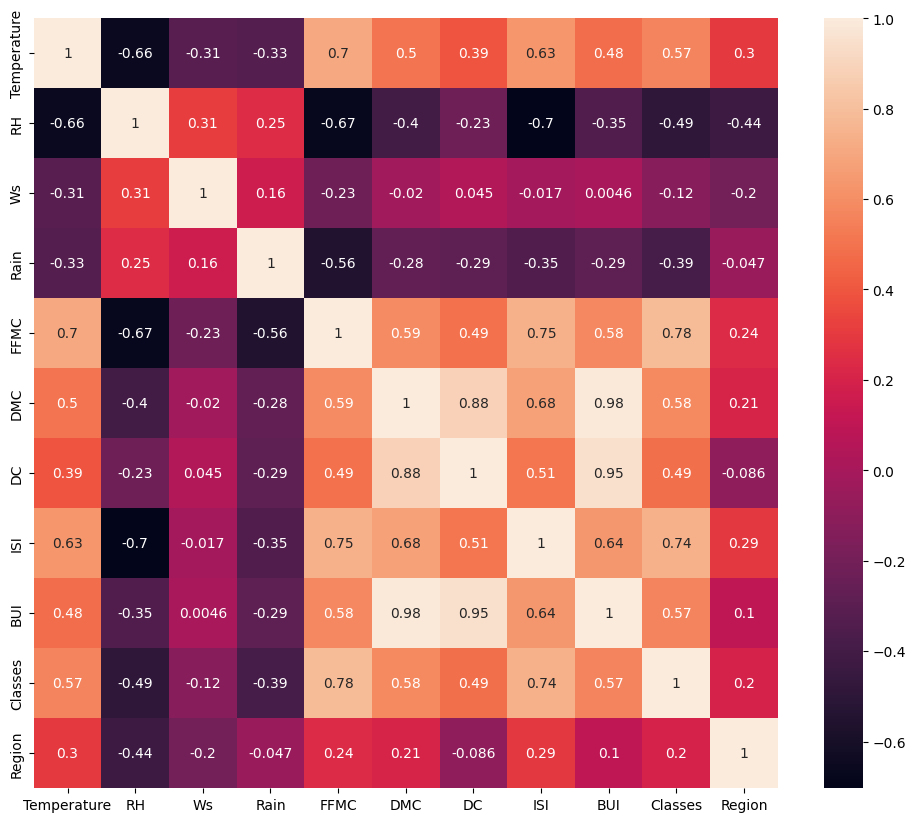

In [37]:
plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr, annot=True)

In [38]:
## Checking for Multicollinearity
def correlation (dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [43]:
## Threshold -- Doman expertise
corr_features = correlation(X_train, 0.85) # Checking feature with collinearity > 90%

In [44]:
## Drop features when correlation more than 0.85
X_train.drop(corr_features, axis=1, inplace=True)
X_test.drop(corr_features, axis=1, inplace=True)
X_train.shape
X_test.shape


(61, 9)

## Feature Scaling or Standardization

In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
X_train_scaled

array([[ 1.02303642, -0.43660011,  0.86738718, ...,  1.21490928,
         0.84674738, -1.        ],
       [-0.87412283,  1.29836103, -0.48477099, ..., -1.11490029,
        -1.18098977,  1.        ],
       [ 0.48099092, -0.22840477,  0.86738718, ...,  0.75380114,
         0.84674738,  1.        ],
       ...,
       [ 0.20996817,  0.25738434, -0.14673145, ..., -0.50817904,
         0.84674738, -1.        ],
       [ 0.48099092,  0.53497813, -0.82281053, ..., -0.21695285,
         0.84674738, -1.        ],
       [-0.06105458, -0.08960788,  0.86738718, ..., -0.65379214,
        -1.18098977, -1.        ]], shape=(182, 9))

In [48]:
X_test_scaled

array([[-0.33207733,  1.22896258, -0.14673145, -0.36324995,  0.49731002,
         1.08147994, -0.0470709 ,  0.84674738, -1.        ],
       [ 0.20996817, -2.44915503, -0.82281053, -0.36324995,  1.10891556,
         0.49313572,  2.25846982,  0.84674738,  1.        ],
       [ 1.02303642, -0.50599856,  0.86738718, -0.36324995,  0.7851244 ,
         0.39642161,  1.16637158,  0.84674738, -1.        ],
       [-0.87412283,  0.88197035, -0.14673145,  0.23332626, -1.36628803,
        -0.8366834 , -0.99355604, -1.18098977,  1.        ],
       [ 1.02303642, -0.02020944,  0.86738718, -0.20054735,  0.12315134,
        -0.27251771, -0.50817904,  0.84674738, -1.        ],
       [ 1.02303642, -0.43660011, -0.14673145, -0.36324995,  0.76353832,
         0.46895719,  0.75380114,  0.84674738,  1.        ],
       [-0.87412283,  1.85354859, -0.82281053, -0.36324995, -0.53882171,
        -1.00593311, -0.89648064, -1.18098977, -1.        ],
       [ 0.48099092,  0.1879859 ,  0.19130809, -0.36324995,  0

### Box Plots To understand Effects of Standard Scaler

Text(0.5, 1.0, 'X_train After Scaling')

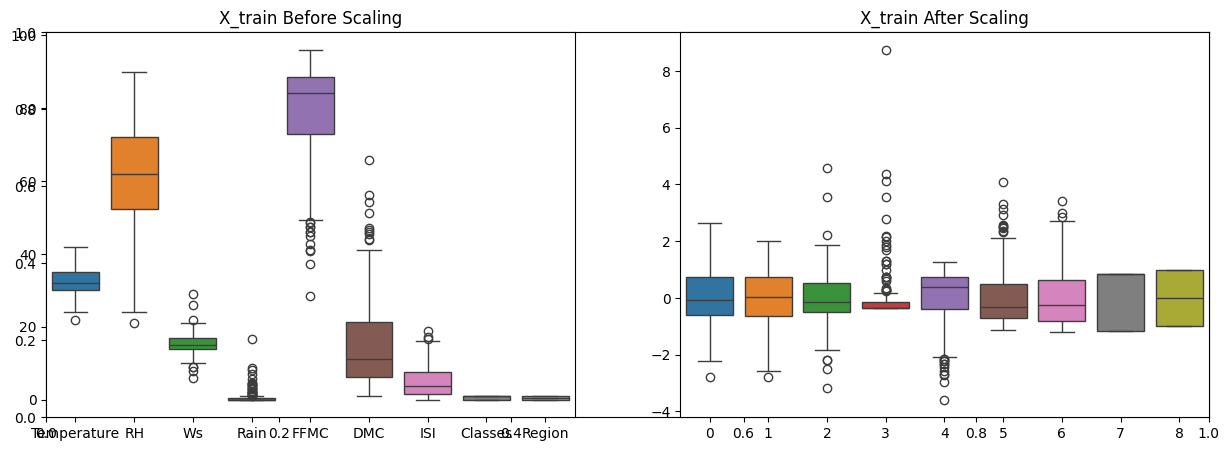

In [49]:
plt.subplots (figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')

### Linear Regression Model

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [59]:
linreg = LinearRegression()
linreg.fit(X_train_scaled, Y_train)
y_pred = linreg.predict(X_test_scaled)


Mean absolute error 0.7080454340692289
R2 score 0.9813991246626835


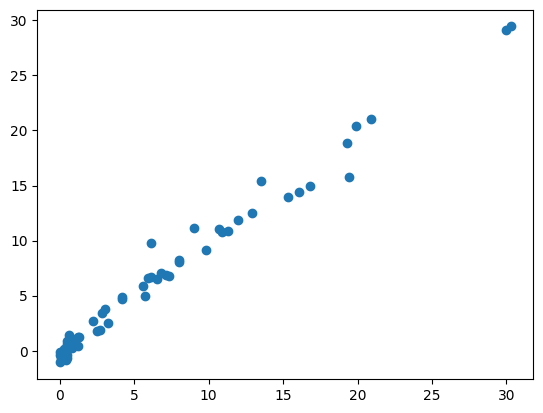

In [61]:
mae = mean_absolute_error(Y_test, y_pred)
score = r2_score(Y_test,y_pred)
print("Mean absolute error", mae)
print("R2 score", score)
plt.scatter(Y_test, y_pred)

## Lasso Regression

Mean absolute error 1.162666559057477
R2 score 0.9524019216349231


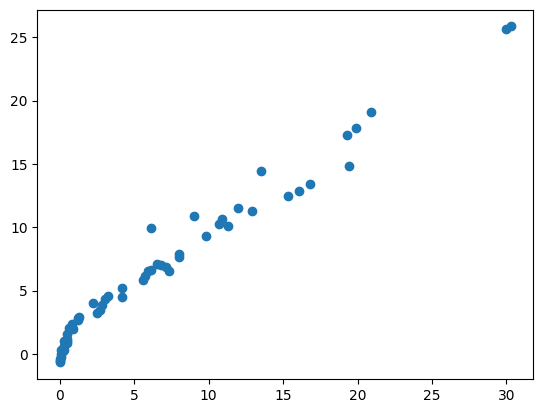

In [63]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

lasso = Lasso()
lasso.fit(X_train_scaled, Y_train)
y_pred = lasso.predict(X_test_scaled)


mae = mean_absolute_error(Y_test, y_pred)
score = r2_score(Y_test,y_pred)
print("Mean absolute error", mae)
print("R2 score", score)
plt.scatter(Y_test, y_pred)

### Ridge Regression

Mean absolute error 0.7285821514895924
R2 score 0.9807982726897482


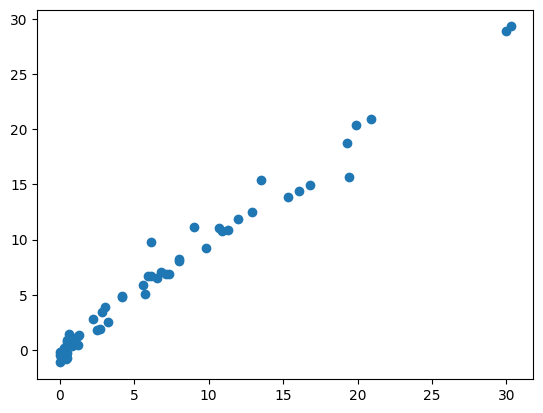

In [65]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

ridge = Ridge()
ridge.fit(X_train_scaled, Y_train)
y_pred = ridge.predict(X_test_scaled)


mae = mean_absolute_error(Y_test, y_pred)
score = r2_score(Y_test,y_pred)
print("Mean absolute error", mae)
print("R2 score", score)
plt.scatter(Y_test, y_pred)

### Elasticnet Regression


Mean absolute error 1.783990002099594
R2 score 0.8868096501682265


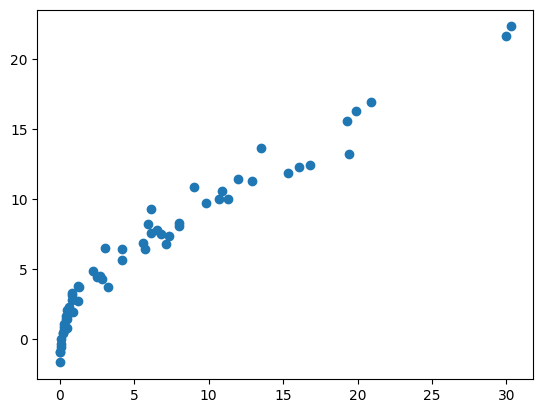

In [66]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

elastic = ElasticNet()
elastic.fit(X_train_scaled, Y_train)
y_pred = elastic.predict(X_test_scaled)


mae = mean_absolute_error(Y_test, y_pred)
score = r2_score(Y_test,y_pred)
print("Mean absolute error", mae)
print("R2 score", score)
plt.scatter(Y_test, y_pred)

### Hyperparameter Tuning

### Cross Validation Lasso

### Lasso CV Model

In [67]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)
lassocv.fit(X_train_scaled, Y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [68]:
lassocv.predict(X_test_scaled)

array([11.17012306, 18.80053855, 14.2043669 , -0.29414604,  4.45257778,
       11.91324607, -0.22711404, 20.23718075, -1.47349134,  6.71128369,
       15.89151888, -0.4686434 , 12.3066646 , 15.34619769,  5.84852439,
        1.36255747,  1.35507864,  2.78908352, 10.86555123,  7.22322977,
        9.87088151, -0.63362732,  8.02146179,  0.99864375, -0.41004092,
        2.1067629 ,  0.40664313, 11.2574235 ,  0.38352119,  4.74613234,
       -0.06881413,  5.4807395 ,  3.59145333,  1.12540643,  0.95011989,
        7.07797288,  6.69369972,  3.23483789,  3.31948473, -0.3791254 ,
       13.70989959, -0.61800092,  1.02464922,  6.74577799, -0.36922482,
        1.45669607, -0.63797409, -0.30979216,  0.85927084,  8.29731489,
       29.19397273, -0.4689966 ,  2.35334042, 20.95679122, -0.73646791,
        6.2971085 , 10.95494744, 28.87546897, -0.7198113 ,  9.30402019,
       14.90315639])

In [69]:
lassocv.alphas_

array([6.80786263, 6.34903547, 5.92113173, 5.52206727, 5.14989842,
       4.8028125 , 4.47911901, 4.17724138, 3.89570929, 3.63315153,
       3.38828927, 3.15992992, 2.94696122, 2.74834589, 2.56311658,
       2.3903711 , 2.22926809, 2.07902288, 1.9389037 , 1.80822808,
       1.68635956, 1.57270457, 1.46670954, 1.36785823, 1.27566916,
       1.18969333, 1.10951198, 1.03473459, 0.96499694, 0.89995937,
       0.83930512, 0.78273877, 0.72998479, 0.68078626, 0.63490355,
       0.59211317, 0.55220673, 0.51498984, 0.48028125, 0.4479119 ,
       0.41772414, 0.38957093, 0.36331515, 0.33882893, 0.31599299,
       0.29469612, 0.27483459, 0.25631166, 0.23903711, 0.22292681,
       0.20790229, 0.19389037, 0.18082281, 0.16863596, 0.15727046,
       0.14667095, 0.13678582, 0.12756692, 0.11896933, 0.1109512 ,
       0.10347346, 0.09649969, 0.08999594, 0.08393051, 0.07827388,
       0.07299848, 0.06807863, 0.06349035, 0.05921132, 0.05522067,
       0.05149898, 0.04802813, 0.04479119, 0.04177241, 0.03895

In [70]:
lassocv.mse_path_

array([[39.68176375, 66.12198634, 60.95324321, 57.01399533, 49.68019702],
       [34.72136703, 62.43346708, 57.03433541, 50.80684634, 44.90295968],
       [30.40374708, 56.25374716, 52.7010811 , 45.52072731, 40.72774111],
       [26.64545698, 50.82417561, 46.6612224 , 40.97143057, 37.07749059],
       [23.37377314, 46.05073593, 40.95211972, 36.15480384, 33.15437073],
       [20.52560509, 41.29406133, 35.97043928, 31.73695975, 29.18074418],
       [18.0459205 , 35.91466398, 31.62259231, 27.92848322, 25.71299574],
       [15.88689204, 31.25433645, 27.82703471, 24.64737038, 22.68541271],
       [14.00685364, 27.21802576, 24.51277529, 21.82359275, 20.04230078],
       [12.36972839, 23.72330696, 21.61806004, 19.3951945 , 17.73383205],
       [10.94395417, 20.69856836, 19.08895439, 17.30881811, 15.71706724],
       [ 9.70212938, 18.0815978 , 16.87866023, 15.51818141, 13.9546166 ],
       [ 8.620413  , 15.81794077, 14.94636695, 13.98314736, 12.41391966],
       [ 7.67806131, 13.8615502 , 13.2

Mean absolute error 0.6907718970484775
R2 score 0.9813858215981922


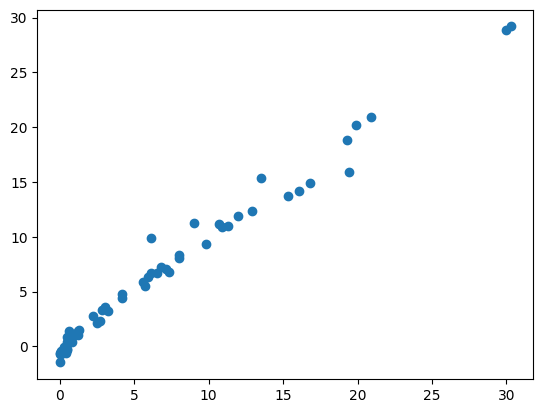

In [73]:
y_pred = lassocv.predict(X_test_scaled)
plt.scatter(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
score = r2_score(Y_test,y_pred)
print("Mean absolute error", mae)
print("R2 score", score)

### Ridge CV Model

Mean absolute error 0.7285821514895924
R2 score 0.9807982726897482


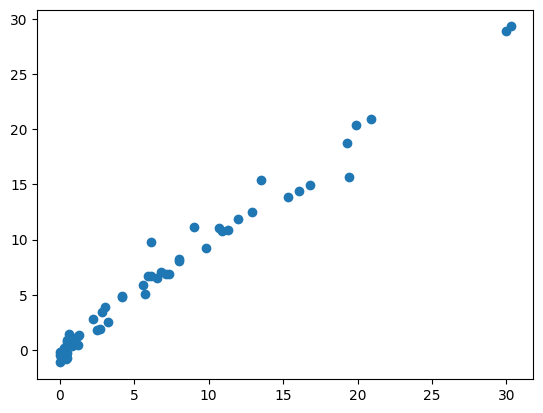

In [77]:
from sklearn.linear_model import RidgeCV
ridgeCV = RidgeCV(cv=5)
ridgeCV.fit(X_train_scaled, Y_train)
y_pred = ridgeCV.predict(X_test_scaled)
plt.scatter(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
score = r2_score(Y_test,y_pred)
print("Mean absolute error", mae)
print("R2 score", score)

### ElasticNet CV Model

Mean absolute error 0.7788502058175136
R2 score 0.9789981817166541


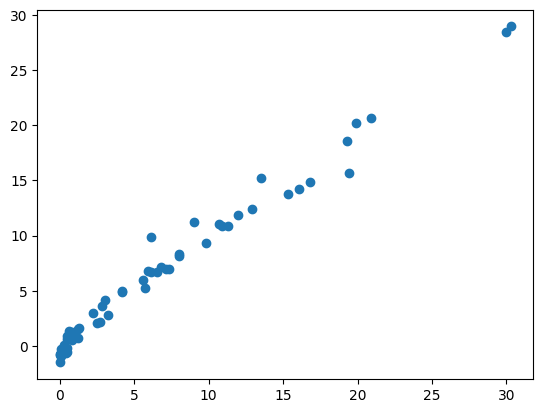

: 

In [ ]:
from sklearn.linear_model import ElasticNetCV
elasticnetCV = ElasticNetCV(cv=5)
elasticnetCV.fit(X_train_scaled, Y_train)
y_pred = elasticnetCV.predict(X_test_scaled)
plt.scatter(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
score = r2_score(Y_test,y_pred)
print("Mean absolute error", mae)
print("R2 score", score)